# 02 — Liquidity & Depth

**Market Microstructure Simulation — Notebook 2**

---

## Mục tiêu

Notebook này khám phá **bốn chiều thanh khoản** của thị trường:

| Chiều | Câu hỏi | Công cụ đo |
|---|---|---|
| **Tightness** (độ chặt) | Spread là bao nhiêu? | Quoted / Effective / Realized spread |
| **Depth** (chiều sâu) | Có bao nhiêu lệnh gần mid? | DepthSnapshot, Liquidity supply curve |
| **Resiliency** (độ bền) | Book phục hồi nhanh cỡ nào sau shock? | LiquidityResilience, half-life |
| **Price impact** (tác động giá) | Mua 1 đơn vị làm giá dịch bao nhiêu? | Amihud, Kyle λ, sqrt impact |

Ngoài ra, chúng ta sẽ xem dealer **tự bảo vệ** như thế nào qua mô hình **Avellaneda-Stoikov inventory-adjusted quotes**.

---

### Dependency
```
structure/
├── state/orderbook.py
└── mechanism/liquidity.py   ← module chính notebook này
```

In [24]:
import sys, pathlib
# Thêm thư mục gốc của package vào path
ROOT = pathlib.Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Import từ package
from src.structure import (
    Quote, DepthSnapshot,
    SpreadDecomposition,
    AmihudIlliquidity, KyleLambda,
    LiquidityResilience,
    InventoryAdjustedQuotes,
    LiquidityTracker,
)

print("✓ Imports OK")

✓ Imports OK


---
## Part 1 — Tightness: Spread và chi phí giao dịch

**Quoted spread** = ask − bid → chi phí lý thuyết của round-trip.  
**Effective spread** = 2·|trade price − mid| → chi phí thực tế khi lệnh được khớp bên trong spread.  
**Realized spread** = effective spread − price impact → phần lợi nhuận dealer giữ lại sau khi adverse price movement.  

Decomposition (Huang-Stoll 1997):
$$\text{Quoted Spread} = \underbrace{\alpha \cdot S}_{\text{adverse selection}} + \underbrace{\beta \cdot S}_{\text{inventory}} + \underbrace{\gamma \cdot S}_{\text{order processing}}$$

In [25]:
rng = np.random.default_rng(42)
T   = 500   # số quan sát

# Mô phỏng chuỗi giá mid với random walk
mid_prices = 100.0 + np.cumsum(rng.normal(0, 0.05, T))

# Spread dao động theo volatility (spread nới rộng khi vol cao)
base_spread = 0.10
vol_factor  = np.abs(rng.normal(1.0, 0.3, T)).clip(0.5, 3.0)
spreads     = base_spread * vol_factor

# Trade signs: +1 buyer-initiated, -1 seller-initiated
# Informed traders tạo serial correlation nhỏ
trade_signs = rng.choice([-1, 1], size=T, p=[0.48, 0.52])  # slight buy imbalance

# Trade prices = mid ± half-spread (takers hit best quote)
trade_prices = mid_prices + trade_signs * spreads / 2 * rng.uniform(0.8, 1.0, T)

# Price changes
price_changes = np.diff(mid_prices, prepend=mid_prices[0])

# ── Decompose spread ──────────────────────────────────────────────────────
decomp = SpreadDecomposition(rho=0.05)   # rho: serial correlation of signs
result = decomp.decompose(
    spreads=spreads,
    trade_signs=trade_signs.astype(float),
    price_changes=price_changes,
)

# ── Effective & Realized spread ───────────────────────────────────────────
eff_spreads = [
    SpreadDecomposition.effective_spread(tp, mp)
    for tp, mp in zip(trade_prices, mid_prices)
]

# Realized spread: compare mid at trade vs mid 5 steps later
realized_spreads = [
    SpreadDecomposition.realized_spread(
        trade_price=trade_prices[i],
        mid_price_t=mid_prices[i],
        mid_price_t5=mid_prices[min(i+5, T-1)],
        sign=int(trade_signs[i]),
    )
    for i in range(T)
]

price_impacts = [
    SpreadDecomposition.price_impact_component(
        mid_price_t=mid_prices[i],
        mid_price_t5=mid_prices[min(i+5, T-1)],
        sign=int(trade_signs[i]),
    )
    for i in range(T)
]

print("Spread Decomposition (Huang-Stoll 1997)")
print(f"  Adverse Selection : {result['adverse_selection']:.1%}")
print(f"  Inventory Cost    : {result['inventory']:.1%}")
print(f"  Order Processing  : {result['order_processing']:.1%}")
print()
print(f"Mean Quoted Spread    : {np.mean(spreads):.4f}")
print(f"Mean Effective Spread : {np.mean(eff_spreads):.4f}")
print(f"Mean Realized Spread  : {np.mean(realized_spreads):.4f}")
print(f"Mean Price Impact     : {np.mean(price_impacts):.4f}")

Spread Decomposition (Huang-Stoll 1997)
  Adverse Selection : 3.5%
  Inventory Cost    : 4.8%
  Order Processing  : 91.7%

Mean Quoted Spread    : 0.0995
Mean Effective Spread : 0.0897
Mean Realized Spread  : 0.0794
Mean Price Impact     : 0.0104


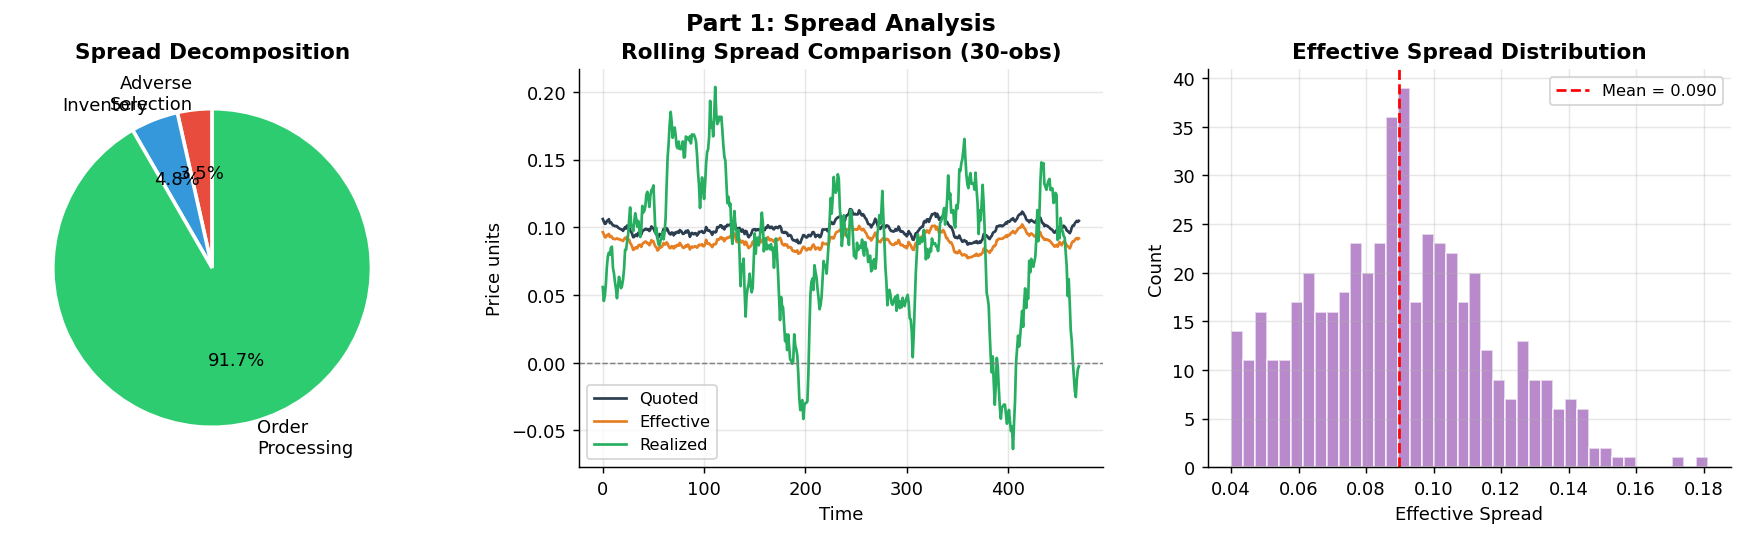

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Pie chart – spread decomposition
ax = axes[0]
labels = ["Adverse\nSelection", "Inventory", "Order\nProcessing"]
sizes  = [result["adverse_selection"], result["inventory"], result["order_processing"]]
colors = ["#e74c3c", "#3498db", "#2ecc71"]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Spread Decomposition", fontweight="bold")

# 2. Rolling spreads over time
ax = axes[1]
window = 30
roll_quoted = np.convolve(spreads, np.ones(window)/window, mode="valid")
roll_eff    = np.convolve(eff_spreads, np.ones(window)/window, mode="valid")
roll_real   = np.convolve(realized_spreads, np.ones(window)/window, mode="valid")
x = np.arange(len(roll_quoted))
ax.plot(x, roll_quoted, label="Quoted",    color="#2c3e50", lw=1.5)
ax.plot(x, roll_eff,    label="Effective", color="#e67e22", lw=1.5)
ax.plot(x, roll_real,   label="Realized",  color="#27ae60", lw=1.5)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Rolling Spread Comparison (30-obs)", fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Price units")
ax.legend(fontsize=9)

# 3. Histogram of effective spread
ax = axes[2]
ax.hist(eff_spreads, bins=40, color="#9b59b6", alpha=0.7, edgecolor="white")
ax.axvline(np.mean(eff_spreads), color="red", lw=1.5, ls="--", label=f"Mean = {np.mean(eff_spreads):.3f}")
ax.set_title("Effective Spread Distribution", fontweight="bold")
ax.set_xlabel("Effective Spread")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 1: Spread Analysis", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Effective spread < Quoted spread** → một phần lệnh được khớp bên trong spread (price improvement).
- **Realized spread ≈ Effective − Price Impact** → phần dealer thực sự kiếm được sau khi giá dịch chuyển bất lợi.
- Khi adverse selection cao (nhiều informed traders), realized spread tiến về 0 hoặc âm → dealer bị thua lỗ.

---
## Part 2 — Depth: Cấu trúc sổ lệnh và chi phí thực thi

**Depth** = tổng khối lượng sẵn có trong sổ lệnh tại các mức giá khác nhau.  
**Liquidity supply curve** = với mỗi kích thước lệnh Q, VWAP thực thi sẽ là bao nhiêu?  
**Slippage** = VWAP − mid (với lệnh mua) → chi phí thực tế vượt quá spread.

In [27]:
def build_depth_snapshot(mid: float, n_levels: int = 10, tick: float = 0.05) -> DepthSnapshot:
    """
    Xây dựng một DepthSnapshot mô phỏng.
    Depth giảm theo hàm mũ khi giá xa mid.
    """
    rng_local = np.random.default_rng(99)
    
    # Bids: giá giảm dần từ mid
    bid_prices = [mid - tick * (i + 1) for i in range(n_levels)]
    bid_qtys   = [rng_local.uniform(50, 200) * np.exp(-0.2 * i) for i in range(n_levels)]
    
    # Asks: giá tăng dần từ mid  
    ask_prices = [mid + tick * (i + 1) for i in range(n_levels)]
    ask_qtys   = [rng_local.uniform(50, 200) * np.exp(-0.2 * i) for i in range(n_levels)]
    
    return DepthSnapshot(
        timestamp=0.0,
        bids=list(zip(bid_prices, bid_qtys)),
        asks=list(zip(ask_prices, ask_qtys)),
        mid_price=mid,
    )


mid = 100.0
snap = build_depth_snapshot(mid, n_levels=15)

# Liquidity supply curve (cost-to-execute)
cum_qty_ask, vwap_ask = snap.liquidity_supply_curve(side="ask")
cum_qty_bid, vwap_bid = snap.liquidity_supply_curve(side="bid")

# Slippage tại các kích thước khác nhau
order_sizes = np.linspace(10, 600, 50)
slippages_buy  = [snap.slippage(q, side="ask") for q in order_sizes]
slippages_sell = [snap.slippage(q, side="bid") for q in order_sizes]

# Depth metrics
print(f"Bid depth (1% band) : {snap.cumulative_bid_depth(0.01):.1f} units")
print(f"Ask depth (1% band) : {snap.cumulative_ask_depth(0.01):.1f} units")
print(f"Depth imbalance     : {snap.depth_imbalance(0.01):.3f}")
print(f"Market impact (Q=100): buy +{snap.slippage(100, 'ask'):.4f} / sell +{snap.slippage(100, 'bid'):.4f}")

Bid depth (1% band) : 708.5 units
Ask depth (1% band) : 679.3 units
Depth imbalance     : 0.021
Market impact (Q=100): buy +0.0500 / sell +0.5560


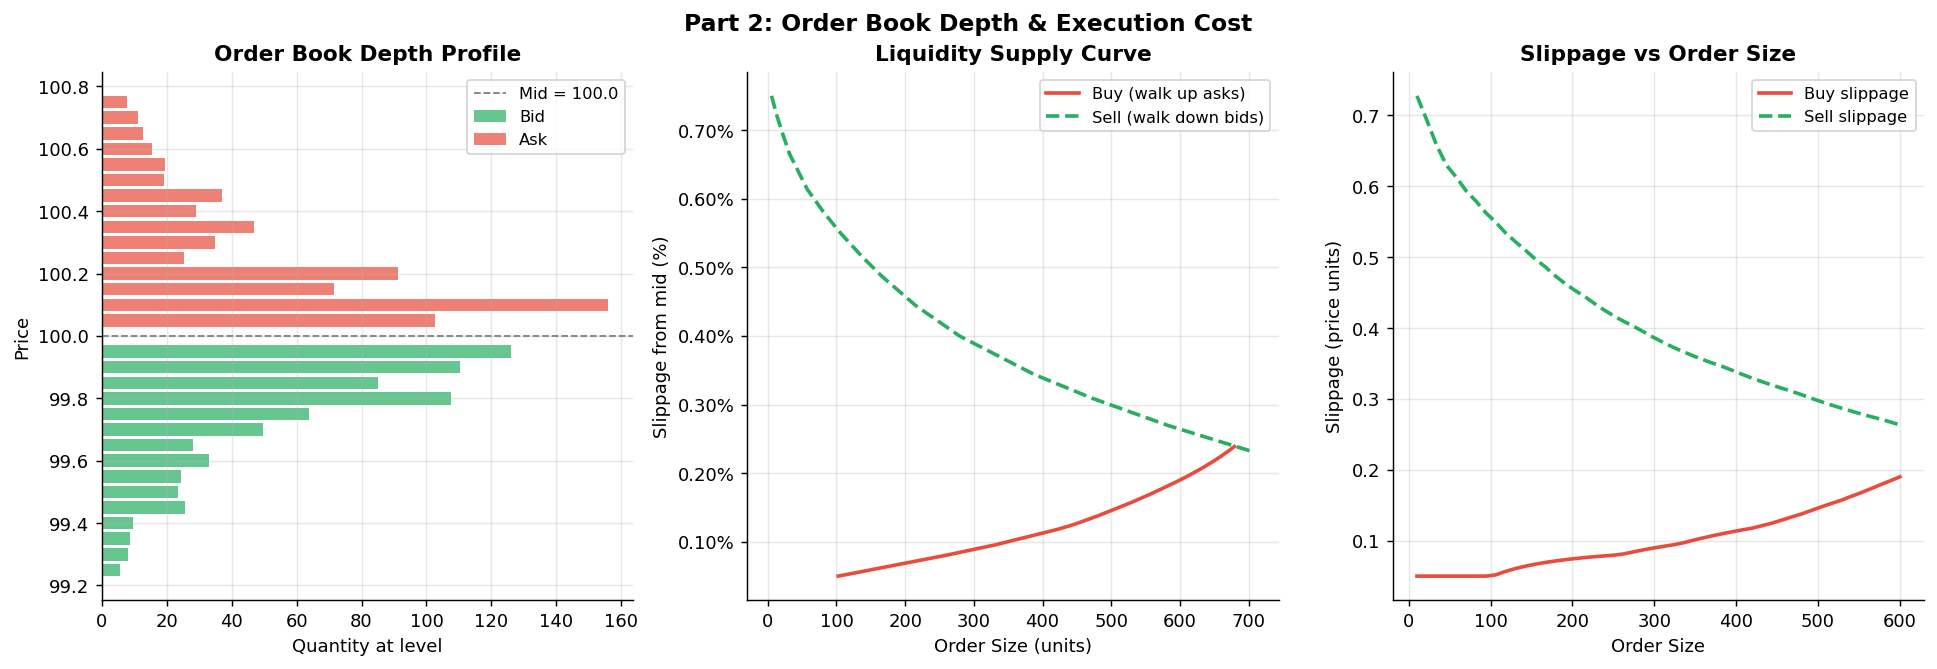

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Order book depth profile (giống biểu đồ market depth)
ax = axes[0]
bid_p = [p for p, _ in snap.bids]
bid_q = [q for _, q in snap.bids]
ask_p = [p for p, _ in snap.asks]
ask_q = [q for _, q in snap.asks]

# Cumulative depth
cum_bid = np.cumsum(bid_q)
cum_ask = np.cumsum(ask_q)

ax.barh(bid_p, bid_q, height=0.04, color="#27ae60", alpha=0.7, label="Bid")
ax.barh(ask_p, ask_q, height=0.04, color="#e74c3c", alpha=0.7, label="Ask")
ax.axhline(mid, color="gray", lw=1, ls="--", label=f"Mid = {mid}")
ax.set_title("Order Book Depth Profile", fontweight="bold")
ax.set_xlabel("Quantity at level")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

# 2. Liquidity supply curve (cost-to-execute)
ax = axes[1]
slippage_ask_pct = (vwap_ask - mid) / mid * 100
slippage_bid_pct = (mid - vwap_bid) / mid * 100
ax.plot(cum_qty_ask, slippage_ask_pct, color="#e74c3c", lw=2, label="Buy (walk up asks)")
ax.plot(cum_qty_bid, slippage_bid_pct, color="#27ae60", lw=2, ls="--", label="Sell (walk down bids)")
ax.set_title("Liquidity Supply Curve", fontweight="bold")
ax.set_xlabel("Order Size (units)")
ax.set_ylabel("Slippage from mid (%)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter())

# 3. Slippage vs order size
ax = axes[2]
valid_buy  = [(q, s) for q, s in zip(order_sizes, slippages_buy)  if s is not None]
valid_sell = [(q, s) for q, s in zip(order_sizes, slippages_sell) if s is not None]

if valid_buy:
    qb, sb = zip(*valid_buy)
    ax.plot(qb, sb, color="#e74c3c", lw=2, label="Buy slippage")
if valid_sell:
    qs, ss = zip(*valid_sell)
    ax.plot(qs, ss, color="#27ae60", lw=2, ls="--", label="Sell slippage")

ax.set_title("Slippage vs Order Size", fontweight="bold")
ax.set_xlabel("Order Size")
ax.set_ylabel("Slippage (price units)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 2: Order Book Depth & Execution Cost", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Liquidity supply curve** dốc lên theo kích thước lệnh — mua càng nhiều thì giá trung bình (VWAP) càng cao so với mid.
- **Depth giảm theo hàm mũ** xa mid → các lệnh lớn chịu slippage phi tuyến.
- Khi **depth imbalance** lệch về phía bid → áp lực bán cao hơn → dự báo giá sẽ giảm (short-term price prediction).

---
## Part 3 — Price Impact: Amihud và Kyle's Lambda

Hai thước đo illiquidity phổ biến nhất:

| Chỉ số | Công thức | Ý nghĩa |
|---|---|---|
| **Amihud ILLIQ** | $\frac{\|r_t\|}{\text{Vol}_t}$ | Price response per dollar traded |
| **Kyle λ** | $\Delta P = \lambda \cdot Q + \varepsilon$ | Permanent price impact per signed volume |
| **Sqrt impact** | $\frac{\Delta P}{\sigma} = \eta \sqrt{Q/\text{ADV}}$ | Non-linear impact for large orders |

In [29]:
rng2 = np.random.default_rng(7)
N = 300

# Mô phỏng 2 chế độ thanh khoản:
# Segment 1 (N//2 đầu): thanh khoản cao
# Segment 2 (N//2 sau): thanh khoản thấp (volume giảm, impact tăng)

volumes_high = rng2.uniform(800, 1200, N//2)
volumes_low  = rng2.uniform(100, 300,  N//2)
volumes = np.concatenate([volumes_high, volumes_low])

# Signed volume
signs = rng2.choice([-1, 1], N)
signed_volumes = signs * volumes

# True price change = lambda * signed_vol + noise
true_lambda_high = 0.00005   # liquid
true_lambda_low  = 0.0003    # illiquid

price_changes_h = true_lambda_high * signed_volumes[:N//2] + rng2.normal(0, 0.01, N//2)
price_changes_l = true_lambda_low  * signed_volumes[N//2:] + rng2.normal(0, 0.02, N//2)
price_changes_all = np.concatenate([price_changes_h, price_changes_l])

# Reconstruct prices & returns
prices_sim  = 100 + np.cumsum(price_changes_all)
returns_sim = np.diff(prices_sim, prepend=prices_sim[0]) / (prices_sim + 1e-10)

# ── Amihud rolling ────────────────────────────────────────────────────────
amihud_rolling = AmihudIlliquidity.rolling(returns_sim, volumes, window=20)

# ── Kyle lambda rolling ───────────────────────────────────────────────────
kyle = KyleLambda(window=40)
lambdas = []
for dp, sv in zip(price_changes_all, signed_volumes):
    lam = kyle.update(dp, sv)
    lambdas.append(lam)
lambdas = np.array([x if x is not None else np.nan for x in lambdas])

# ── Square-root impact ────────────────────────────────────────────────────
order_sizes_sqrt = np.linspace(100, 5000, 100)
daily_vol  = np.std(returns_sim) * np.sqrt(252)
adv_liquid = np.mean(volumes_high) * 252
adv_illiq  = np.mean(volumes_low)  * 252

impact_liquid = [KyleLambda.sqrt_impact(q, daily_vol, adv_liquid, eta=0.1) for q in order_sizes_sqrt]
impact_illiq  = [KyleLambda.sqrt_impact(q, daily_vol, adv_illiq,  eta=0.1) for q in order_sizes_sqrt]

# One-shot Kyle estimate for each regime
lambda_high_est = KyleLambda.estimate(price_changes_h, signed_volumes[:N//2])
lambda_low_est  = KyleLambda.estimate(price_changes_l, signed_volumes[N//2:])

print(f"Kyle λ — Liquid regime   : {lambda_high_est:.6f}")
print(f"Kyle λ — Illiquid regime : {lambda_low_est:.6f}")
print(f"Ratio                    : {lambda_low_est / lambda_high_est:.1f}x more impact in illiquid market")

Kyle λ — Liquid regime   : 0.000052
Kyle λ — Illiquid regime : 0.000307
Ratio                    : 6.0x more impact in illiquid market


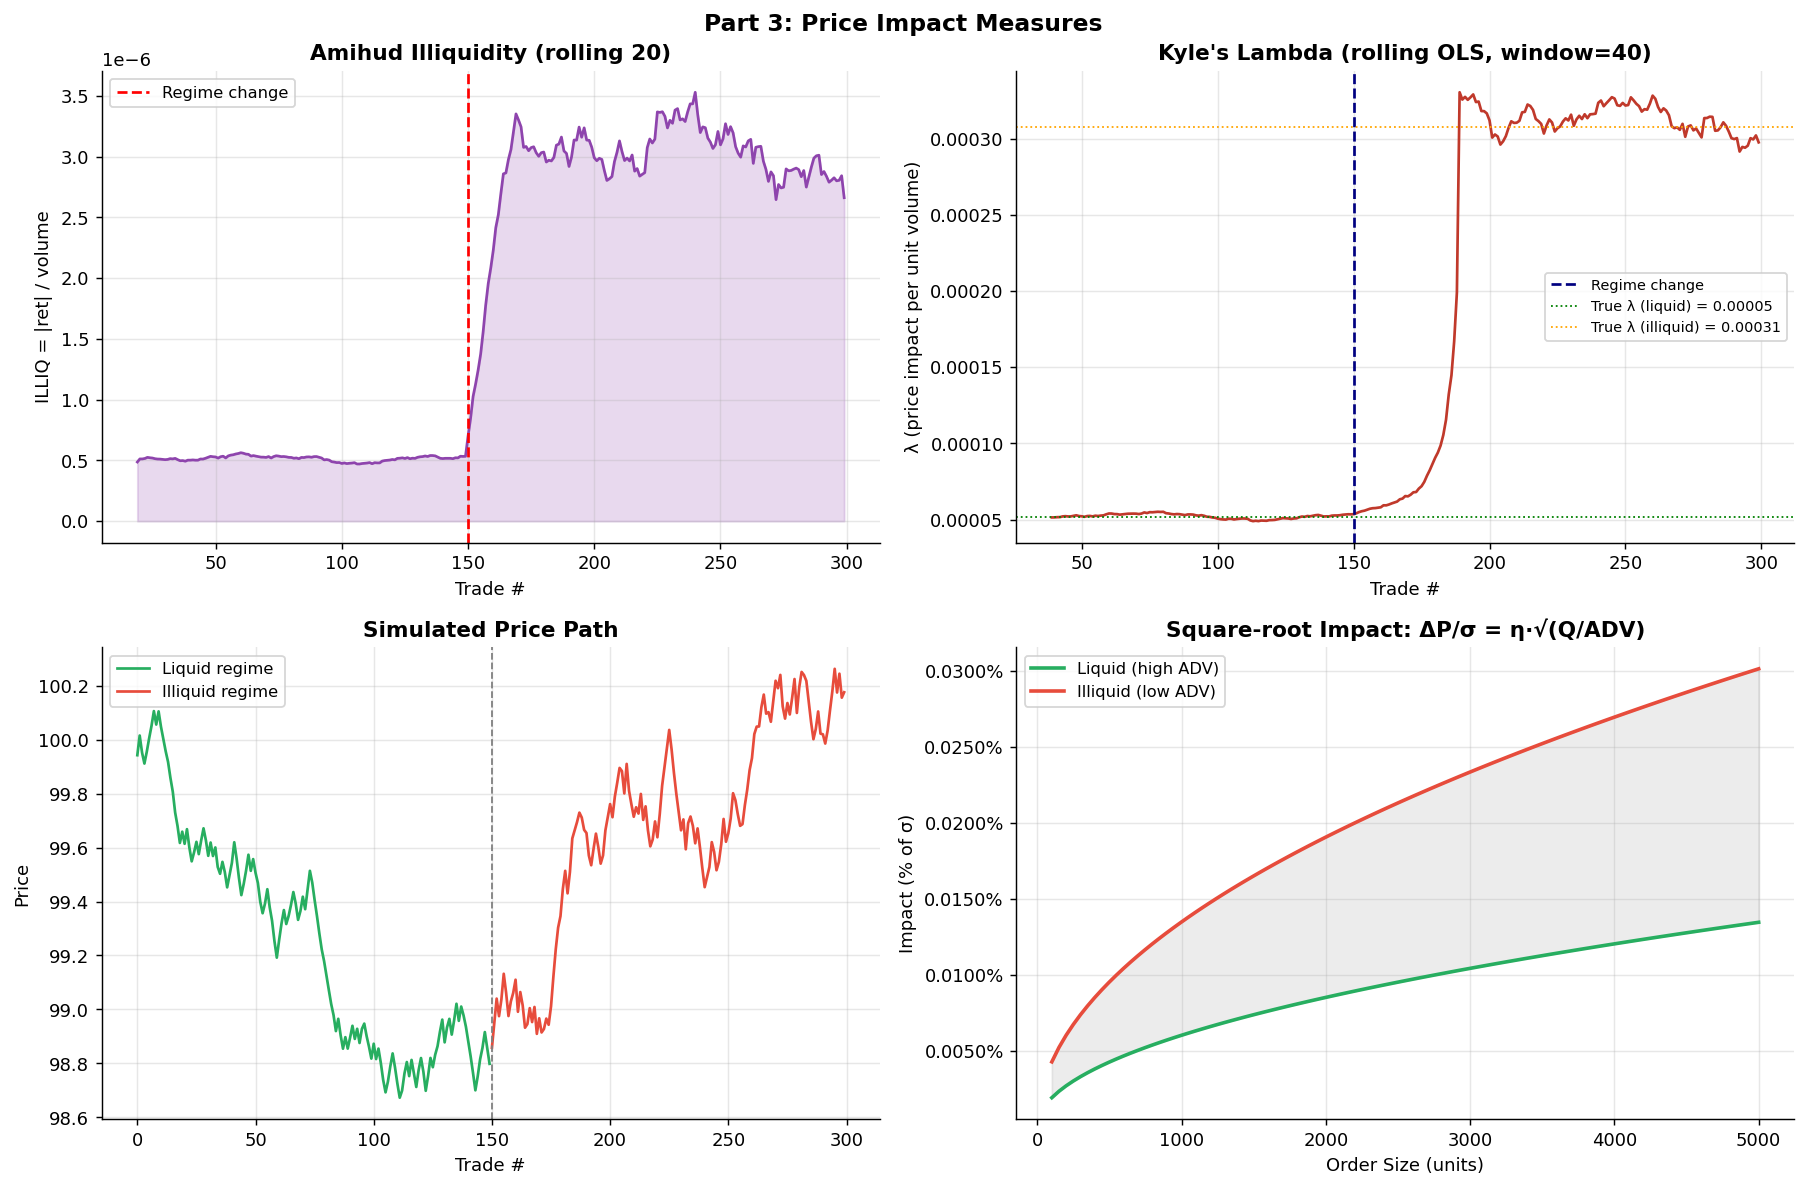

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Rolling Amihud illiquidity
ax = axes[0, 0]
ax.plot(amihud_rolling, color="#8e44ad", lw=1.5)
ax.axvline(N//2, color="red", lw=1.5, ls="--", label="Regime change")
ax.fill_between(range(N), amihud_rolling,
                where=~np.isnan(amihud_rolling), alpha=0.2, color="#8e44ad")
ax.set_title("Amihud Illiquidity (rolling 20)", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("ILLIQ = |ret| / volume")
ax.legend(fontsize=9)

# 2. Rolling Kyle Lambda
ax = axes[0, 1]
ax.plot(lambdas, color="#c0392b", lw=1.5)
ax.axvline(N//2, color="navy", lw=1.5, ls="--", label="Regime change")
ax.axhline(lambda_high_est, color="green", lw=1, ls=":", label=f"True λ (liquid) = {lambda_high_est:.5f}")
ax.axhline(lambda_low_est, color="orange", lw=1, ls=":", label=f"True λ (illiquid) = {lambda_low_est:.5f}")
ax.set_title("Kyle's Lambda (rolling OLS, window=40)", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("λ (price impact per unit volume)")
ax.legend(fontsize=8)

# 3. Price path with regime
ax = axes[1, 0]
ax.plot(prices_sim[:N//2], color="#27ae60", lw=1.5, label="Liquid regime")
ax.plot(range(N//2, N), prices_sim[N//2:], color="#e74c3c", lw=1.5, label="Illiquid regime")
ax.axvline(N//2, color="gray", lw=1, ls="--")
ax.set_title("Simulated Price Path", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

# 4. Square-root impact model
ax = axes[1, 1]
pct_impact_liquid = np.array(impact_liquid) * 100
pct_impact_illiq  = np.array(impact_illiq)  * 100
ax.plot(order_sizes_sqrt, pct_impact_liquid, color="#27ae60", lw=2, label="Liquid (high ADV)")
ax.plot(order_sizes_sqrt, pct_impact_illiq,  color="#e74c3c", lw=2, label="Illiquid (low ADV)")
ax.fill_between(order_sizes_sqrt, pct_impact_liquid, pct_impact_illiq, alpha=0.15, color="gray")
ax.set_title("Square-root Impact: ΔP/σ = η·√(Q/ADV)", fontweight="bold")
ax.set_xlabel("Order Size (units)")
ax.set_ylabel("Impact (% of σ)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.suptitle("Part 3: Price Impact Measures", y=1.01, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Amihud** và **Kyle λ** cùng tăng vọt khi regime chuyển sang illiquid — hai chỉ số này tương quan cao nhưng đo các góc độ khác nhau (Amihud: price-per-dollar, Kyle: price-per-signed-unit).
- **Square-root impact** phi tuyến: giá trị là sublinear trong Q → splitting order làm giảm tổng impact. Đây là nền tảng của các thuật toán TWAP/VWAP execution.
- Trong thị trường illiquid, phải trade với ADV thấp nên slippage tăng rất mạnh.

---
## Part 4 — Resiliency: Book phục hồi sau shock

**Resiliency** = tốc độ depth phục hồi sau một lệnh lớn ăn vào sổ.

Mô hình phục hồi theo hàm mũ:
$$D(t) = D_\infty \cdot \left(1 - e^{-\kappa t}\right)$$

- **$\kappa$ lớn** → phục hồi nhanh → thị trường resilient.
- **Half-life** $= \ln(2)/\kappa$ → thời gian để phục hồi 50% depth.

In [31]:
rng3 = np.random.default_rng(13)

def simulate_resilience(kappa: float, D_inf: float, noise: float = 2.0):
    """Mô phỏng quá trình phục hồi depth sau shock.
    t_max = 5 half-lives để OLS có đủ data ở mọi tốc độ phục hồi.
    """
    t_max = 5 * np.log(2) / kappa
    times  = np.linspace(0, t_max, 200)
    depths = D_inf * (1 - np.exp(-kappa * times)) + rng3.normal(0, noise, len(times))
    return times, np.clip(depths, 0, None)

# Ba kịch bản
scenarios = {
    "High Resilience (κ=0.15)": 0.15,
    "Medium Resilience (κ=0.05)": 0.05,
    "Low Resilience (κ=0.01)": 0.01,
}

D_inf = 500.0  # pre-shock depth

# Tính half-life và κ ước lượng bằng LiquidityResilience
results_resilience = {}
for name, kappa in scenarios.items():
    times, depths = simulate_resilience(kappa, D_inf)
    
    res = LiquidityResilience()
    res.register_shock(depth_before=D_inf, t=0.0)
    for t, d in zip(times, depths):
        res.observe(d, t)
    
    kappa_est = res.recovery_rate()
    hl_est    = res.half_life()
    hl_true   = np.log(2) / kappa
    
    results_resilience[name] = {
        "times": times, "depths": depths,
        "kappa_true": kappa, "kappa_est": kappa_est,
        "hl_true": hl_true, "hl_est": hl_est,
    }
    print(f"{name}")
    print(f"  True κ={kappa:.3f} → est κ={kappa_est:.3f}" if kappa_est else f"  True κ={kappa:.3f} → est=N/A")
    print(f"  True half-life={hl_true:.1f}s → est={hl_est:.1f}s" if hl_est else f"  True half-life={hl_true:.1f}s")
    print()

High Resilience (κ=0.15)
  True κ=0.150 → est κ=0.151
  True half-life=4.6s → est=4.6s

Medium Resilience (κ=0.05)
  True κ=0.050 → est κ=0.050
  True half-life=13.9s → est=13.8s

Low Resilience (κ=0.01)
  True κ=0.010 → est κ=0.010
  True half-life=69.3s → est=68.4s



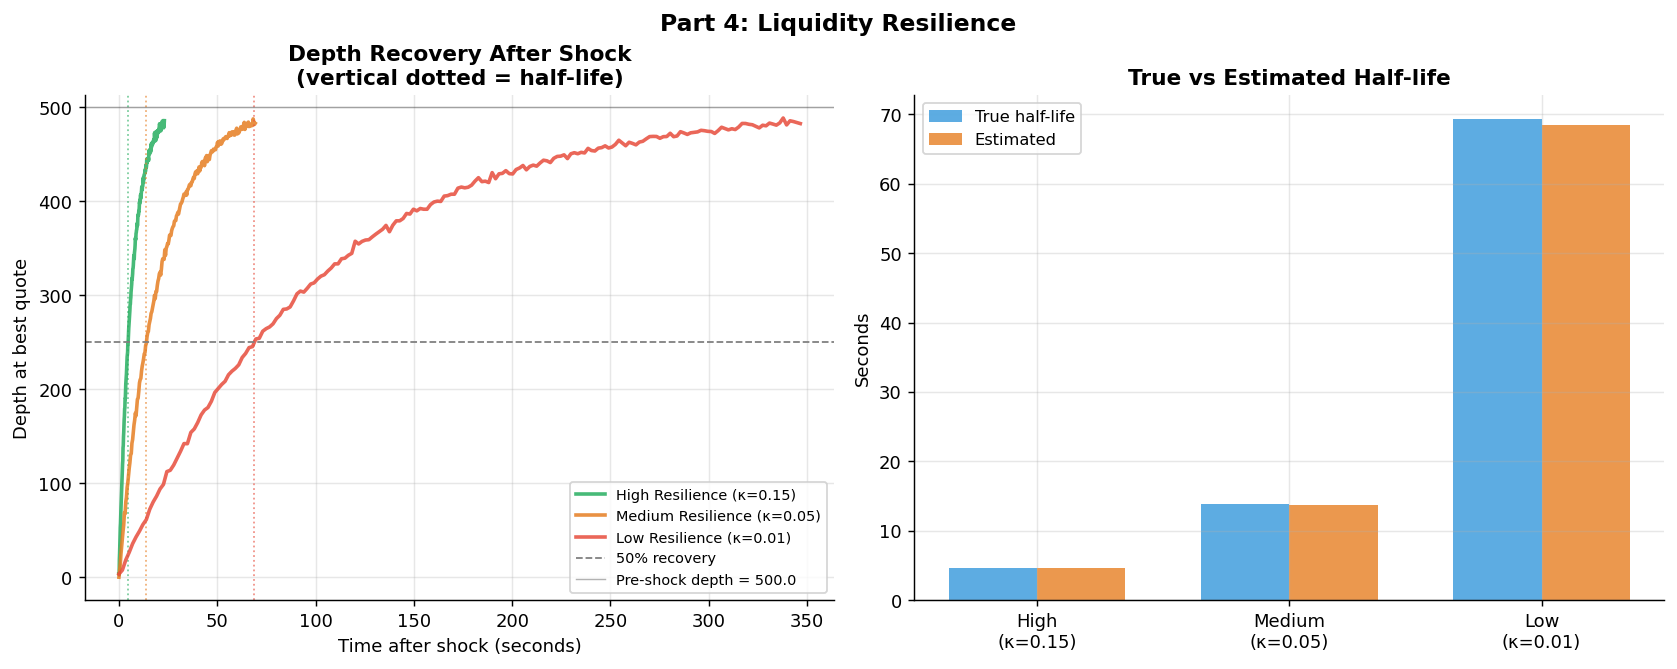

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#27ae60", "#e67e22", "#e74c3c"]

# 1. Recovery curves
ax = axes[0]
for (name, data), color in zip(results_resilience.items(), colors):
    ax.plot(data["times"], data["depths"], lw=2, color=color, label=name, alpha=0.85)
    if data["hl_est"]:
        ax.axvline(data["hl_est"], color=color, lw=1, ls=":", alpha=0.6)

ax.axhline(D_inf / 2, color="gray", lw=1, ls="--", label="50% recovery")
ax.axhline(D_inf, color="black", lw=0.8, ls="-", alpha=0.3, label=f"Pre-shock depth = {D_inf}")
ax.set_title("Depth Recovery After Shock\n(vertical dotted = half-life)", fontweight="bold")
ax.set_xlabel("Time after shock (seconds)")
ax.set_ylabel("Depth at best quote")
ax.legend(fontsize=8, loc="lower right")

# 2. Bar chart: half-life comparison
ax = axes[1]
names_short = ["High\n(κ=0.15)", "Medium\n(κ=0.05)", "Low\n(κ=0.01)"]
hl_trues = [np.log(2)/k for k in scenarios.values()]
hl_ests  = [v["hl_est"] if v["hl_est"] else 0 for v in results_resilience.values()]

x = np.arange(len(names_short))
width = 0.35
ax.bar(x - width/2, hl_trues, width, label="True half-life", color="#3498db", alpha=0.8)
ax.bar(x + width/2, hl_ests,  width, label="Estimated",      color="#e67e22", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names_short, fontsize=10)
ax.set_title("True vs Estimated Half-life", fontweight="bold")
ax.set_ylabel("Seconds")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 4: Liquidity Resilience", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- Thị trường với **κ cao** phục hồi trong vài giây → market maker quay lại post quotes rất nhanh.
- Thị trường với **κ thấp** có thể mất hàng phút để depth trở về mức bình thường → window of opportunity cho predatory trading.
- **Resiliency ≠ Depth**: một thị trường có thể có depth lớn nhưng kém resilient nếu market maker rút lui sau shock.

---
## Part 5 — Inventory-Adjusted Quotes (Avellaneda-Stoikov)

Dealer không quote symmetric khi inventory ≠ 0.  

**Reservation price** (giá mà dealer sẵn sàng giao dịch):
$$r(s,q,t) = s - q \cdot \gamma \cdot \sigma^2 \cdot (T-t)$$

Spread tối ưu:
$$\delta^{ask} + \delta^{bid} = \gamma \sigma^2 (T-t) + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa}\right)$$

Intuition: **Long inventory → hạ ask, nâng bid** để khuyến khích bán ra và tái cân bằng.

In [33]:
ias = InventoryAdjustedQuotes(
    gamma=0.1,
    base_spread=0.05,
    inventory_penalty=0.002,
    skew_factor=0.004,
    max_inventory=500.0,
)

mid_price  = 100.0
volatility = 0.02

# Inventory từ -500 (short) đến +500 (long)
inventories = np.linspace(-500, 500, 200)

bids, asks, spreads_inv, mids_adj = [], [], [], []
for inv in inventories:
    b, a = ias.quotes(mid_price, inv, volatility, time_remaining=1.0)
    bids.append(b)
    asks.append(a)
    spreads_inv.append(a - b)
    mids_adj.append((a + b) / 2)

# Dynamics: mô phỏng dealer inventory theo thời gian
rng4 = np.random.default_rng(21)
T_dyn  = 200
inv_ts = [0.0]   # bắt đầu flat
bid_ts, ask_ts, mid_ts = [], [], []

for step in range(T_dyn):
    inv = inv_ts[-1]
    b, a = ias.quotes(mid_price, inv, volatility, time_remaining=1 - step/T_dyn)
    bid_ts.append(b)
    ask_ts.append(a)
    mid_ts.append((a + b) / 2)
    
    # Random fills: buy/sell arrive with probability proportional to quote aggressiveness
    # Long inventory → ask tighter → more sells → inventory mean-reverts
    p_buy  = 0.5 * (1 + (mid_price - a) / (mid_price * 0.01 + 1e-10))
    p_buy  = np.clip(p_buy, 0.1, 0.9)
    p_sell = 1.0 - p_buy
    action = rng4.choice(["buy", "sell"], p=[p_buy, p_sell])
    if action == "buy":
        inv_ts.append(inv + rng4.uniform(5, 30))
    elif action == "sell":
        inv_ts.append(inv - rng4.uniform(5, 30))
    else:
        inv_ts.append(inv)

print("Inventory Adjusted Quotes — Sample")
for inv_ex in [-400, -200, 0, 200, 400]:
    b, a = ias.quotes(mid_price, inv_ex, volatility)
    print(f"  Inventory={inv_ex:+4d} → Bid={b:.4f}, Ask={a:.4f}, Spread={a-b:.4f}, Mid_adj={(a+b)/2:.4f}")

Inventory Adjusted Quotes — Sample
  Inventory=-400 → Bid=99.4950, Ask=101.1450, Spread=1.6501, Mid_adj=100.3200
  Inventory=-200 → Bid=99.7350, Ask=100.5850, Spread=0.8501, Mid_adj=100.1600
  Inventory=  +0 → Bid=99.9750, Ask=100.0250, Spread=0.0501, Mid_adj=100.0000
  Inventory=+200 → Bid=99.4150, Ask=100.2650, Spread=0.8501, Mid_adj=99.8400
  Inventory=+400 → Bid=98.8550, Ask=100.5050, Spread=1.6501, Mid_adj=99.6800


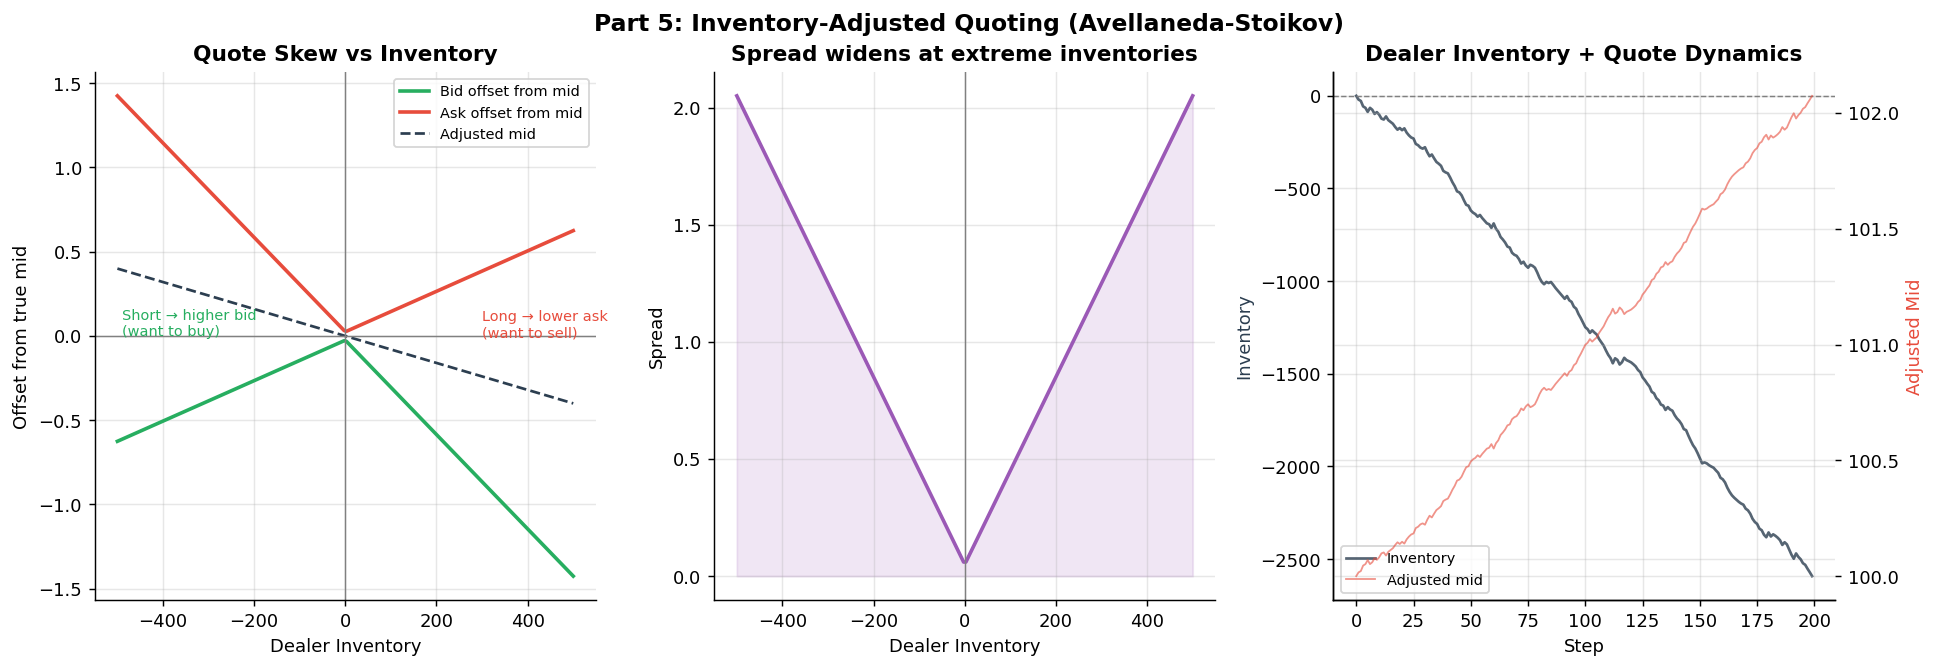

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Quote skew as function of inventory
ax = axes[0]
ax.plot(inventories, np.array(bids) - mid_price,  color="#27ae60", lw=2, label="Bid offset from mid")
ax.plot(inventories, np.array(asks) - mid_price,  color="#e74c3c", lw=2, label="Ask offset from mid")
ax.plot(inventories, np.array(mids_adj) - mid_price, color="#2c3e50", lw=1.5, ls="--", label="Adjusted mid")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_title("Quote Skew vs Inventory", fontweight="bold")
ax.set_xlabel("Dealer Inventory")
ax.set_ylabel("Offset from true mid")
ax.legend(fontsize=8)
ax.annotate("Long → lower ask\n(want to sell)", xy=(300, -0.005), fontsize=8, color="#e74c3c")
ax.annotate("Short → higher bid\n(want to buy)", xy=(-490, 0.003), fontsize=8, color="#27ae60")

# 2. Spread widening with inventory
ax = axes[1]
ax.plot(inventories, spreads_inv, color="#9b59b6", lw=2)
ax.axvline(0, color="gray", lw=0.8)
ax.fill_between(inventories, spreads_inv, alpha=0.15, color="#9b59b6")
ax.set_title("Quoted Spread vs Inventory", fontweight="bold")
ax.set_xlabel("Dealer Inventory")
ax.set_ylabel("Spread")
ax.set_title("Spread widens at extreme inventories", fontweight="bold")

# 3. Inventory dynamics + quote adjustment
ax = axes[2]
ax2 = ax.twinx()
ax.plot(inv_ts[:T_dyn], color="#2c3e50", lw=1.5, alpha=0.8, label="Inventory")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax2.plot(mid_ts, color="#e74c3c", lw=1, alpha=0.6, label="Adjusted mid")
ax.set_title("Dealer Inventory + Quote Dynamics", fontweight="bold")
ax.set_xlabel("Step")
ax.set_ylabel("Inventory", color="#2c3e50")
ax2.set_ylabel("Adjusted Mid", color="#e74c3c")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.suptitle("Part 5: Inventory-Adjusted Quoting (Avellaneda-Stoikov)", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- Khi dealer **long** inventory lớn, họ hạ ask và nâng bid → khuyến khích flow bán vào để tái cân bằng.
- **Spread mở rộng** ở cả hai đầu cực của inventory — dealer yêu cầu phần bù rủi ro cao hơn.
- Cơ chế này tạo ra **mean-reversion trong inventory** → quan trọng cho stability của thị trường.

---
## Part 6 — LiquidityTracker: Rolling Dashboard

Trong thực tế, cần theo dõi tất cả metrics trên trong thời gian thực. `LiquidityTracker` tổng hợp toàn bộ thành một rolling dashboard.

In [35]:
rng5 = np.random.default_rng(55)
T_track = 400

tracker = LiquidityTracker(window=50)

# Mô phỏng regime thay đổi: bình thường → stressed (t=200) → phục hồi (t=320)
def get_regime(t):
    if t < 200:
        return "normal"
    elif t < 320:
        return "stressed"
    else:
        return "recovery"

spread_params = {"normal": (0.08, 0.02), "stressed": (0.35, 0.10), "recovery": (0.15, 0.04)}
depth_params  = {"normal": (200, 30),    "stressed": (60, 20),     "recovery": (130, 25)}
vol_params    = {"normal": 800,          "stressed": 200,          "recovery": 500}

price_track = 100.0
snapshots_metrics = []

for t in range(T_track):
    regime = get_regime(t)
    s_mu, s_sd = spread_params[regime]
    d_mu, d_sd = depth_params[regime]
    v_base     = vol_params[regime]
    
    spread = abs(rng5.normal(s_mu, s_sd))
    depth  = abs(rng5.normal(d_mu, d_sd))
    vol    = abs(rng5.normal(v_base, v_base * 0.2))
    sign   = rng5.choice([-1, 1])
    
    price_track += sign * spread * 0.3 + rng5.normal(0, 0.02)
    
    q = Quote(
        timestamp=float(t),
        bid_price=price_track - spread/2,
        bid_qty=depth,
        ask_price=price_track + spread/2,
        ask_qty=depth * rng5.uniform(0.8, 1.2),
    )
    tracker.update_quote(q)
    tracker.update_trade(price_track, vol, sign)
    
    if t % 10 == 0:
        m = tracker.snapshot_metrics()
        m["t"] = t
        m["regime"] = regime
        snapshots_metrics.append(m)

import pandas as pd
df_metrics = pd.DataFrame(snapshots_metrics).set_index("t")
summary = df_metrics.groupby("regime")[["spread_mean", "bid_depth_mean", "kyle_lambda", "amihud_illiq"]].mean()
print("\nLiquidity metrics by regime:")
with pd.option_context('display.float_format', '{:.2e}'.format):
    print(summary)


Liquidity metrics by regime:
          spread_mean  bid_depth_mean  kyle_lambda  amihud_illiq
regime                                                          
normal       8.11e-02        1.96e+02     3.04e-05      3.45e-07
recovery     2.27e-01        1.08e+02     1.78e-04      2.55e-06
stressed     2.81e-01        9.31e+01     3.46e-04      4.47e-06


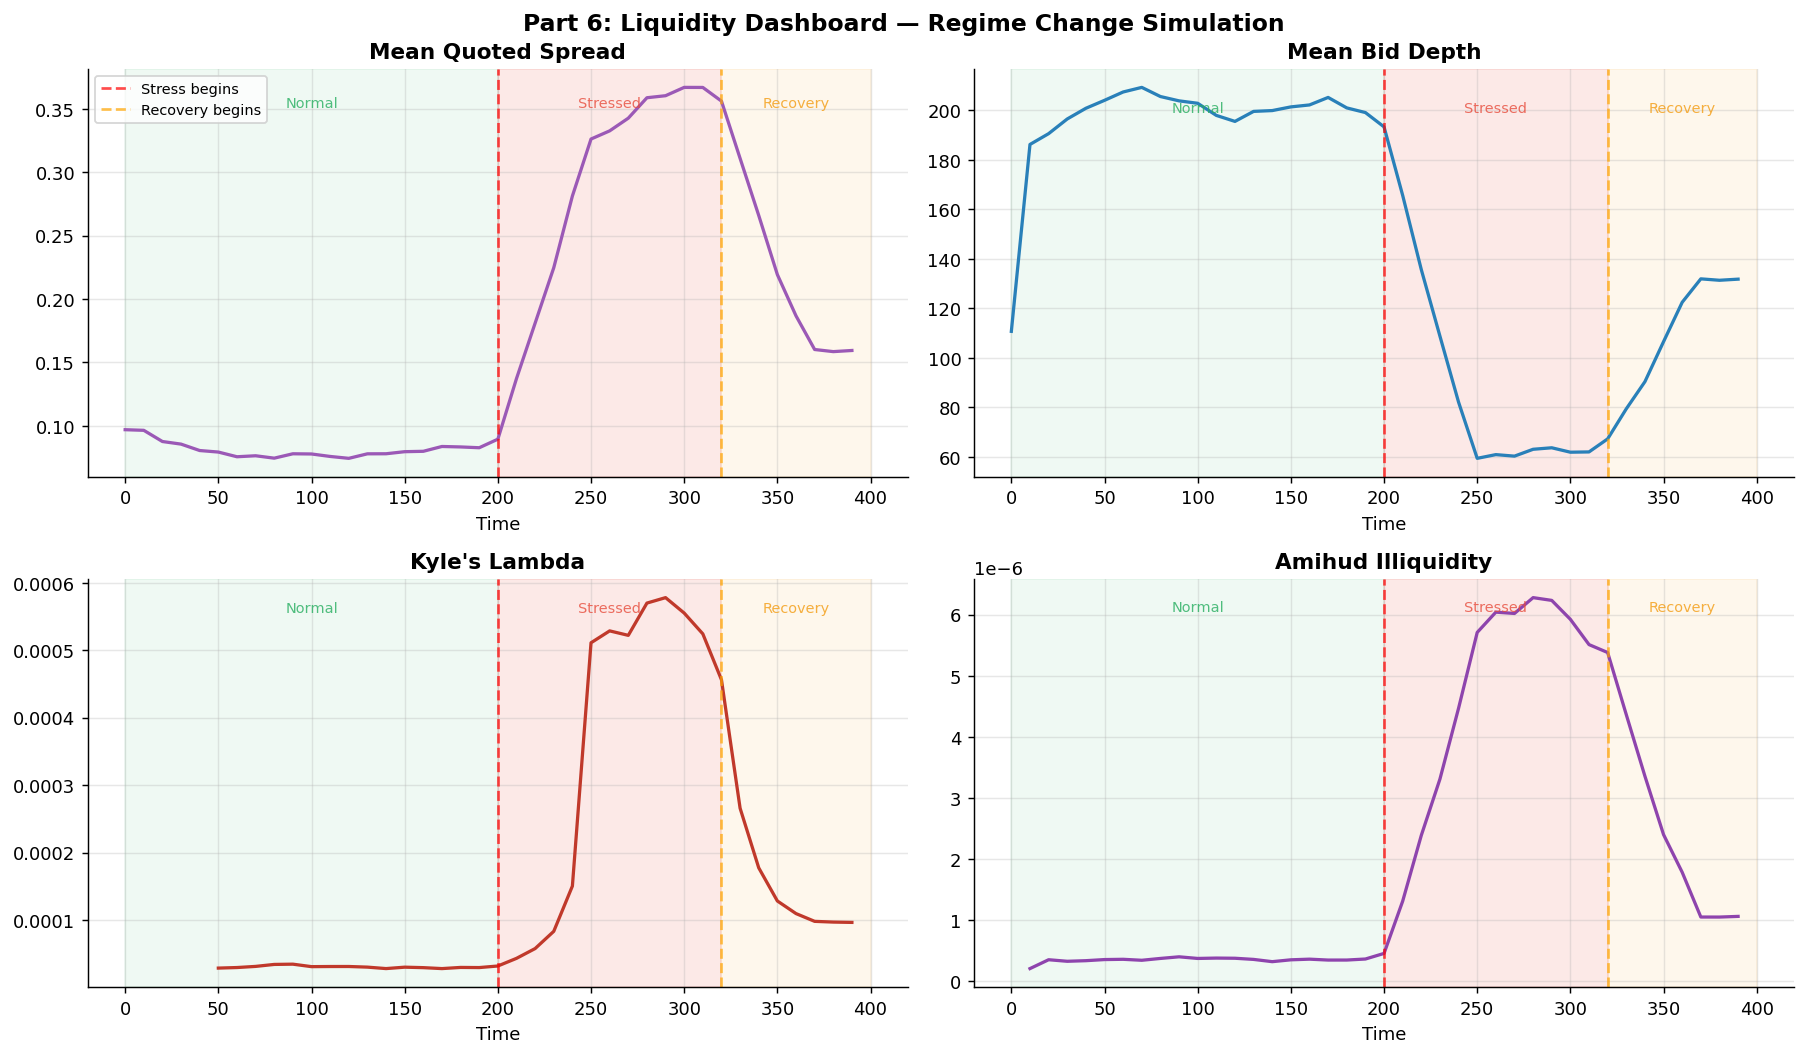

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

regime_colors = {"normal": "#27ae60", "stressed": "#e74c3c", "recovery": "#f39c12"}

for ax_idx, (metric, title, color) in enumerate([
    ("spread_mean",    "Mean Quoted Spread",   "#9b59b6"),
    ("bid_depth_mean", "Mean Bid Depth",        "#2980b9"),
    ("kyle_lambda",    "Kyle's Lambda",          "#c0392b"),
    ("amihud_illiq",   "Amihud Illiquidity",     "#8e44ad"),
]):
    ax = axes[ax_idx // 2, ax_idx % 2]
    
    series = df_metrics[metric].dropna()
    
    # Shade regimes
    ax.axvspan(0,   200, alpha=0.07, color="#27ae60")
    ax.axvspan(200, 320, alpha=0.12, color="#e74c3c")
    ax.axvspan(320, T_track, alpha=0.08, color="#f39c12")
    
    ax.plot(series.index, series.values, color=color, lw=1.8)
    ax.axvline(200, color="red",    lw=1.5, ls="--", alpha=0.7, label="Stress begins")
    ax.axvline(320, color="orange", lw=1.5, ls="--", alpha=0.7, label="Recovery begins")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Time")
    if ax_idx == 0:
        ax.legend(fontsize=8)

# Add regime labels to first plot
for ax in axes.flat:
    ax.text(100, ax.get_ylim()[1] * 0.92, "Normal", ha="center", color="#27ae60", fontsize=8, alpha=0.8)
    ax.text(260, ax.get_ylim()[1] * 0.92, "Stressed", ha="center", color="#e74c3c", fontsize=8, alpha=0.8)
    ax.text(360, ax.get_ylim()[1] * 0.92, "Recovery", ha="center", color="#f39c12", fontsize=8, alpha=0.8)

plt.tight_layout()
plt.suptitle("Part 6: Liquidity Dashboard — Regime Change Simulation", y=1.01, fontsize=13, fontweight="bold")
plt.show()

---
## Tổng kết: Bản đồ thanh khoản

| Chiều | Chỉ số | Tính chất | Dùng khi nào |
|---|---|---|---|
| Tightness | Quoted / Effective / Realized spread | Đơn giản, real-time | Luôn luôn |
| Depth | Cumulative depth, depth imbalance | Level 2 data cần thiết | Timing entries lớn |
| Impact | Amihud ILLIQ | Chỉ cần EOD data | Cross-asset comparison |
| Impact | Kyle λ | Intraday, cần signed flow | Market microstructure research |
| Impact | Sqrt model | Execution optimization | Algo trading / OMS |
| Resiliency | Half-life of depth | Tốn data, cần timestamps | Post-trade analysis |
| Supply | Dealer inventory model | A-S framework | Market making |

### Key Insights

1. **Liquidity là đa chiều** — một thị trường có thể tight nhưng shallow, hoặc deep nhưng kém resilient.
2. **Amihud ≈ Kyle trong cùng regime**, nhưng Kyle đo *signed* impact (hướng) còn Amihud đo absolute impact.
3. **Spread decomposition** cho thấy chi phí giao dịch không thuần túy là order processing — adverse selection chiếm tỷ lệ đáng kể khi có nhiều informed traders.
4. **Inventory adjustment** là self-defense mechanism của dealer — khi bỏ qua inventory risk, market maker sẽ bị adverse selection và mất tiền.
5. **Liquidity có tính regime** — stress events làm tất cả chiều tệ đi cùng lúc (spread tăng, depth giảm, impact tăng) → **liquidity spiral**.

---
**Notebook tiếp theo:** `03_price_formation.ipynb` — Cơ chế hình thành giá, information aggregation, và price discovery.